# Compare trained models

Loads training summaries and evaluation outputs for a session, aggregates key metrics across models, and plots overall comparisons plus validation trajectories.

In [17]:
import sys
from pathlib import Path

# Prefer local src/ over any installed package to ensure using the local code.
sys.path.insert(0, str((Path("..").resolve() / "src")))

In [18]:
import json
from pathlib import Path
from typing import Dict, Iterable, List
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- PATH SETUP ---
current_dir = Path.cwd()
if (current_dir / "training_runs").exists():
    RUNS_ROOT = current_dir / "training_runs"
elif (current_dir.parent / "training_runs").exists():
    RUNS_ROOT = current_dir.parent / "training_runs"
else:
    raise FileNotFoundError(f"Could not find 'training_runs' in {current_dir} or parent.")

PLOTS_DIR = Path("plots") / "04_compare_networks"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Runs Root: {RUNS_ROOT.resolve()}")
print(f"Plots Dir: {PLOTS_DIR.resolve()}")

# --- CONFIGURATION ---
EXCLUDE_RUN_DIRS: List[str] = []  # e.g., ["old_run_a", "debug_experiment"]

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 5)

# --- DISCOVERY LOGIC ---
def discover_runs(runs_root: Path, exclude_dirs: List[str]) -> List[Path]:
    run_dirs: List[Path] = []
    for path in runs_root.iterdir():
        if not path.is_dir():
            continue
        if path.name in exclude_dirs:
            continue
        if not (path / "config.json").exists():
            continue
        run_dirs.append(path)
    run_dirs.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return run_dirs

# --- PLOTTING SETUP ---
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})

RUN_DIRS = discover_runs(RUNS_ROOT, EXCLUDE_RUN_DIRS)
print(f"Found {len(RUN_DIRS)} run(s) under {RUNS_ROOT}. Excluded: {EXCLUDE_RUN_DIRS or 'none'}")


Runs Root: /home/tim/repos/ipeo-hurricane-damage-detection/training_runs
Plots Dir: /home/tim/repos/ipeo-hurricane-damage-detection/plots/04_compare_networks
Found 16 run(s) under /home/tim/repos/ipeo-hurricane-damage-detection/training_runs. Excluded: none


## Load runs and build comparison table

Experiments are auto-discovered from `training_runs` for the chosen session; set `EXCLUDE_EXPERIMENTS` to omit any.
Reads configs, training summaries, and evaluation metrics for each experiment, plus keeps per-epoch histories for trajectory plots.

In [19]:
def infer_dataset_tag(run_name: str) -> str:
    name = (run_name or "").lower()
    if "resample" in name or "resampled" in name:
        return "resampled"
    if "original" in name:
        return "original"
    return "original"


def load_run(run_dir: Path, used_names: set):
    cfg_path = run_dir / "config.json"
    train_summary_path = run_dir / "train_summary.json"
    eval_metrics_path = run_dir / "eval_metrics.json"

    if not cfg_path.exists() or not train_summary_path.exists():
        print(f"Missing config or train_summary for {run_dir.name}, skipping.")
        return None, None

    cfg = json.loads(cfg_path.read_text())
    train_summary = json.loads(train_summary_path.read_text())
    eval_metrics = json.loads(eval_metrics_path.read_text()) if eval_metrics_path.exists() else {}

    history = train_summary.get("history") or []
    for idx, row in enumerate(history):
        if "epoch" not in row:
            row["epoch"] = idx

    base_name = cfg.get("model_name") or run_dir.name
    experiment = base_name if base_name not in used_names else f"{base_name} ({run_dir.name})"
    used_names.add(experiment)

    dataset_tag = infer_dataset_tag(run_dir.name)

    row = {
        "experiment": experiment,
        "run_name": run_dir.name,
        "dataset": dataset_tag,
        "run_dir": str(run_dir),
        "model": cfg.get("model_name"),
        "image_size": cfg.get("image_size"),
        "batch_size": cfg.get("batch_size"),
        "epochs_ran": len(history),
        "best_epoch": train_summary.get("best_epoch"),
        "best_val_macro_f1": train_summary.get("best_metric"),
        "temperature": eval_metrics.get("temperature"),
    }

    for split in ("val_raw", "val_calibrated", "test_raw", "test_calibrated"):
        metrics = eval_metrics.get(split) or {}
        for k, v in metrics.items():
            row[f"{split}_{k}"] = v

    return row, history


def build_palette(labels: Iterable[str]) -> Dict[str, tuple]:
    labels = list(labels)
    if not labels:
        return {}
    base = sns.color_palette("tab20", n_colors=min(len(labels), 20))
    if len(labels) > len(base):
        base = sns.color_palette("husl", len(labels))
    return {label: base[i % len(base)] for i, label in enumerate(labels)}


def annotate_bars(ax, fmt: str = "{:.3f}", padding: int = 4):
    for container in ax.containers:
        if not len(container):
            continue
        labels = [fmt.format(v) if v is not None and not np.isnan(v) else "" for v in container.datavalues]
        ax.bar_label(container, labels=labels, padding=padding, fontsize=9, color="#1f2933")


def annotate_best_points(ax, data: pd.DataFrame, metric: str, palette: Dict[str, tuple], higher_is_better: bool = True):
    experiments = sorted(data["experiment"].unique().tolist())
    if not experiments:
        return
    offsets = np.linspace(10, -10, num=max(len(experiments), 2))
    for offset, exp in zip(offsets, experiments):
        exp_df = data[data["experiment"] == exp]
        if exp_df.empty:
            continue
        selector = exp_df[metric].idxmax() if higher_is_better else exp_df[metric].idxmin()
        best_row = exp_df.loc[selector]
        color = palette.get(exp, "#1f2933")
        ax.scatter(
            best_row["epoch"],
            best_row[metric],
            color=color,
            s=48,
            edgecolor="white",
            linewidth=0.8,
            zorder=4,
        )
        ax.annotate(
            f"ep {int(best_row['epoch'])} {best_row[metric]:.4f}",
            (best_row["epoch"], best_row[metric]),
            textcoords="offset points",
            xytext=(0, offset),
            ha="center",
            fontsize=8,
            color=color,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="none", alpha=0.6),
        )


rows = []
history_frames = []
used_names = set()

for run_dir in RUN_DIRS:
    row, history = load_run(run_dir, used_names)
    if row:
        rows.append(row)
    if row and history:
        hist_df = pd.DataFrame(history)
        if not hist_df.empty:
            if "epoch" not in hist_df.columns:
                hist_df["epoch"] = range(len(hist_df))
            hist_df["experiment"] = row["experiment"]
            hist_df["dataset"] = row["dataset"]
            history_frames.append(hist_df)

comparison_df = pd.DataFrame(rows)
if not comparison_df.empty:
    comparison_df = comparison_df.sort_values("experiment").reset_index(drop=True)
    print(f"Loaded metrics for {len(comparison_df)} run(s).")

history_df = pd.concat(history_frames, ignore_index=True) if history_frames else pd.DataFrame()
if not history_df.empty:
    history_df = history_df.sort_values(["experiment", "epoch"]).reset_index(drop=True)

comparison_df


Loaded metrics for 16 run(s).


,experiment,run_name,dataset,run_dir,model,image_size,batch_size,epochs_ran,best_epoch,best_val_macro_f1,temperature,val_raw_accuracy,val_raw_macro_precision,val_raw_macro_recall,val_raw_macro_f1,val_raw_brier,val_raw_ece,val_calibrated_accuracy,val_calibrated_macro_precision,val_calibrated_macro_recall,val_calibrated_macro_f1,val_calibrated_brier,val_calibrated_ece,test_raw_accuracy,test_raw_macro_precision,test_raw_macro_recall,test_raw_macro_f1,test_raw_brier,test_raw_ece,test_calibrated_accuracy,test_calibrated_macro_precision,test_calibrated_macro_recall,test_calibrated_macro_f1,test_calibrated_brier,test_calibrated_ece
0,convnext_small,resampled_20251210-214142_convnext_small,resampled,/home/tim/repos/ipeo-hurricane-damage-detectio...,convnext_small,256,32,19,6,0.93605,0.94193,0.97374,0.94625,0.92647,0.93605,0.02257,0.01708,0.97374,0.94625,0.92647,0.93605,0.02253,0.00951,0.87589,0.85844,0.79971,0.82265,0.10352,0.07424,0.87589,0.85844,0.79971,0.82265,0.10480,0.07861
1,convnext_small (original_20251210-201837_convn...,original_20251210-201837_convnext_small,original,/home/tim/repos/ipeo-hurricane-damage-detectio...,convnext_small,256,32,17,4,0.98600,0.79777,0.98600,0.98603,0.98600,0.98600,0.01382,0.03819,0.98600,0.98603,0.98600,0.98600,0.01276,0.02142,0.98500,0.98500,0.98500,0.98500,0.01420,0.03732,0.98500,0.98500,0.98500,0.98500,0.01317,0.01751
2,convnext_tiny,resampled_20251210-214142_convnext_tiny,resampled,/home/tim/repos/ipeo-hurricane-damage-detectio...,convnext_tiny,256,48,35,22,0.95573,0.91642,0.98182,0.96638,0.94571,0.95573,0.01766,0.02332,0.98182,0.96638,0.94571,0.95573,0.01752,0.01249,0.90248,0.89651,0.83820,0.86180,0.08205,0.05222,0.90248,0.89651,0.83820,0.86180,0.08345,0.06076
3,convnext_tiny (original_20251210-201837_convne...,original_20251210-201837_convnext_tiny,original,/home/tim/repos/ipeo-hurricane-damage-detectio...,convnext_tiny,256,48,28,15,0.98950,0.81685,0.98950,0.98952,0.98950,0.98950,0.01001,0.02988,0.98950,0.98952,0.98950,0.98950,0.00934,0.01427,0.99000,0.99001,0.99000,0.99000,0.00950,0.03006,0.99000,0.99001,0.99000,0.99000,0.00872,0.01274
4,custom_cnn,original_20251211-044753_custom_cnn,original,/home/tim/repos/ipeo-hurricane-damage-detectio...,custom_cnn,256,96,48,35,0.95799,0.69972,0.95800,0.95831,0.95800,0.95799,0.03452,0.06471,0.95800,0.95831,0.95800,0.95799,0.03030,0.02283,0.95150,0.95219,0.95150,0.95148,0.03724,0.05592,0.95150,0.95219,0.95150,0.95148,0.03376,0.02358
5,custom_cnn (resampled_20251210-214142_custom_cnn),resampled_20251210-214142_custom_cnn,resampled,/home/tim/repos/ipeo-hurricane-damage-detectio...,custom_cnn,256,96,39,26,0.82633,0.97419,0.91717,0.79450,0.87238,0.82633,0.06290,0.01709,0.91717,0.79450,0.87238,0.82633,0.06288,0.01625,0.84929,0.80515,0.78761,0.79563,0.10928,0.05559,0.84929,0.80515,0.78761,0.79563,0.10980,0.05831
6,efficientnet_b1,resampled_20251210-214142_efficientnet_b1,resampled,/home/tim/repos/ipeo-hurricane-damage-detectio...,efficientnet_b1,240,48,39,26,0.96657,0.86427,0.98586,0.96322,0.96999,0.96657,0.01303,0.02928,0.98586,0.96322,0.96999,0.96657,0.01282,0.01548,0.90603,0.92334,0.82681,0.86142,0.08037,0.05025,0.90603,0.92334,0.82681,0.86142,0.08249,0.06279
7,efficientnet_b1 (original_20251210-201837_effi...,original_20251210-201837_efficientnet_b1,original,/home/tim/repos/ipeo-hurricane-damage-detectio...,efficientnet_b1,240,48,18,5,0.66769,1.20114,0.69800,0.81172,0.69800,0.66769,0.23215,0.21326,0.69800,0.81172,0.69800,0.66769,0.21990,0.18960,0.70300,0.81140,0.70300,0.67469,0.23040,0.20848,0.70300,0.81140,0.70300,0.67469,0.21832,0.18454
8,efficientnet_b2,resampled_20251210-214142_efficientnet_b2,resampled,/home/tim/repos/ipeo-hurricane-damage-detectio...,efficientnet_b2,260,36,17,4,0.93700,0.94488,0.97374,0.94027,0.93380,0.93700,0.02470,0.02356,0.97374,0.94027,0.93380,0.93700,0.02464,0.02011,0.85727,0.87462,0.73787,0.77465,0.11642,0.08865,0.85727,0.87462,0.73787,0.77465,0.11789,0.09472
9,efficientnet_b2 (original_20251210-201837_effi...,original_20251210-

## Overview table

Quick glance at the key metrics pulled from evaluation outputs.

In [20]:
if comparison_df.empty:
    print("No runs to plot. Ensure training/evaluation outputs exist under training_runs.")
else:
    metric_cols = [col for col in ("test_calibrated_macro_f1", "test_raw_macro_f1") if col in comparison_df.columns]
    ece_cols = [col for col in ("test_calibrated_ece", "test_raw_ece") if col in comparison_df.columns]
    display_cols = [
        "experiment",
        "run_name",
        "model",
        "image_size",
        "batch_size",
        "epochs_ran",
        "best_epoch",
        "best_val_macro_f1",
    ]
    display_cols += metric_cols + ece_cols
    if "temperature" in comparison_df.columns:
        display_cols.append("temperature")

    overview = comparison_df[display_cols]
    if metric_cols:
        overview = overview.sort_values(metric_cols[0], ascending=False)
    overview = overview.reset_index(drop=True)

overview

,experiment,run_name,model,image_size,batch_size,epochs_ran,best_epoch,best_val_macro_f1,test_calibrated_macro_f1,test_raw_macro_f1,test_calibrated_ece,test_raw_ece,temperature
0,convnext_tiny (original_20251210-201837_convne...,original_20251210-201837_convnext_tiny,convnext_tiny,256,48,28,15,0.98950,0.99000,0.99000,0.01274,0.03006,0.81685
1,convnext_small (original_20251210-201837_convn...,original_20251210-201837_convnext_small,convnext_small,256,32,17,4,0.98600,0.98500,0.98500,0.01751,0.03732,0.79777
2,resnet18 (original_20251210-201837_resnet18),original_20251210-201837_resnet18,resnet18,256,64,15,2,0.98450,0.98300,0.98300,0.01188,0.02466,0.84144
3,resnet34 (original_20251210-201837_resnet34),original_20251210-201837_resnet34,resnet34,256,48,20,7,0.98050,0.98200,0.98200,0.01509,0.03001,0.82858
4,custom_cnn,original_20251211-044753_custom_cnn,custom_cnn,256,96,48,35,0.95799,0.95148,0.95148,0.02358,0.05592,0.69972
5,resnet50,resampled_20251210-214142_resnet50,resnet50,256,32,46,33,0.94391,0.89092,0.89092,0.03591,0.02922,0.92497
6,convnext_tiny,resampled_20251210-214142_convnext_tiny,convnext_tiny,256,48,35,22,0.95573,0.86180,0.86180,0.06076,0.05222,0.91642
7,efficientnet_b1,resampled_20251210-214142_efficientnet_b1,efficientnet_b1,240,48,39,26,0.96657,0.86142,0.86142,0.06279,0.05025,0.86427
8,resnet18,resampled_20251210-214142_resnet18,resnet18,256,64,28,15,0.93456,0.85728,0.85728,0.04366,0.03662,0.93277
9,convnext_small,resampled_20251210-214142_convnext_small,convnext_small,256,32,19,6,0.93605,0.82265,0.82265,0.07861,0.07424,0.94193


## Comparison plots

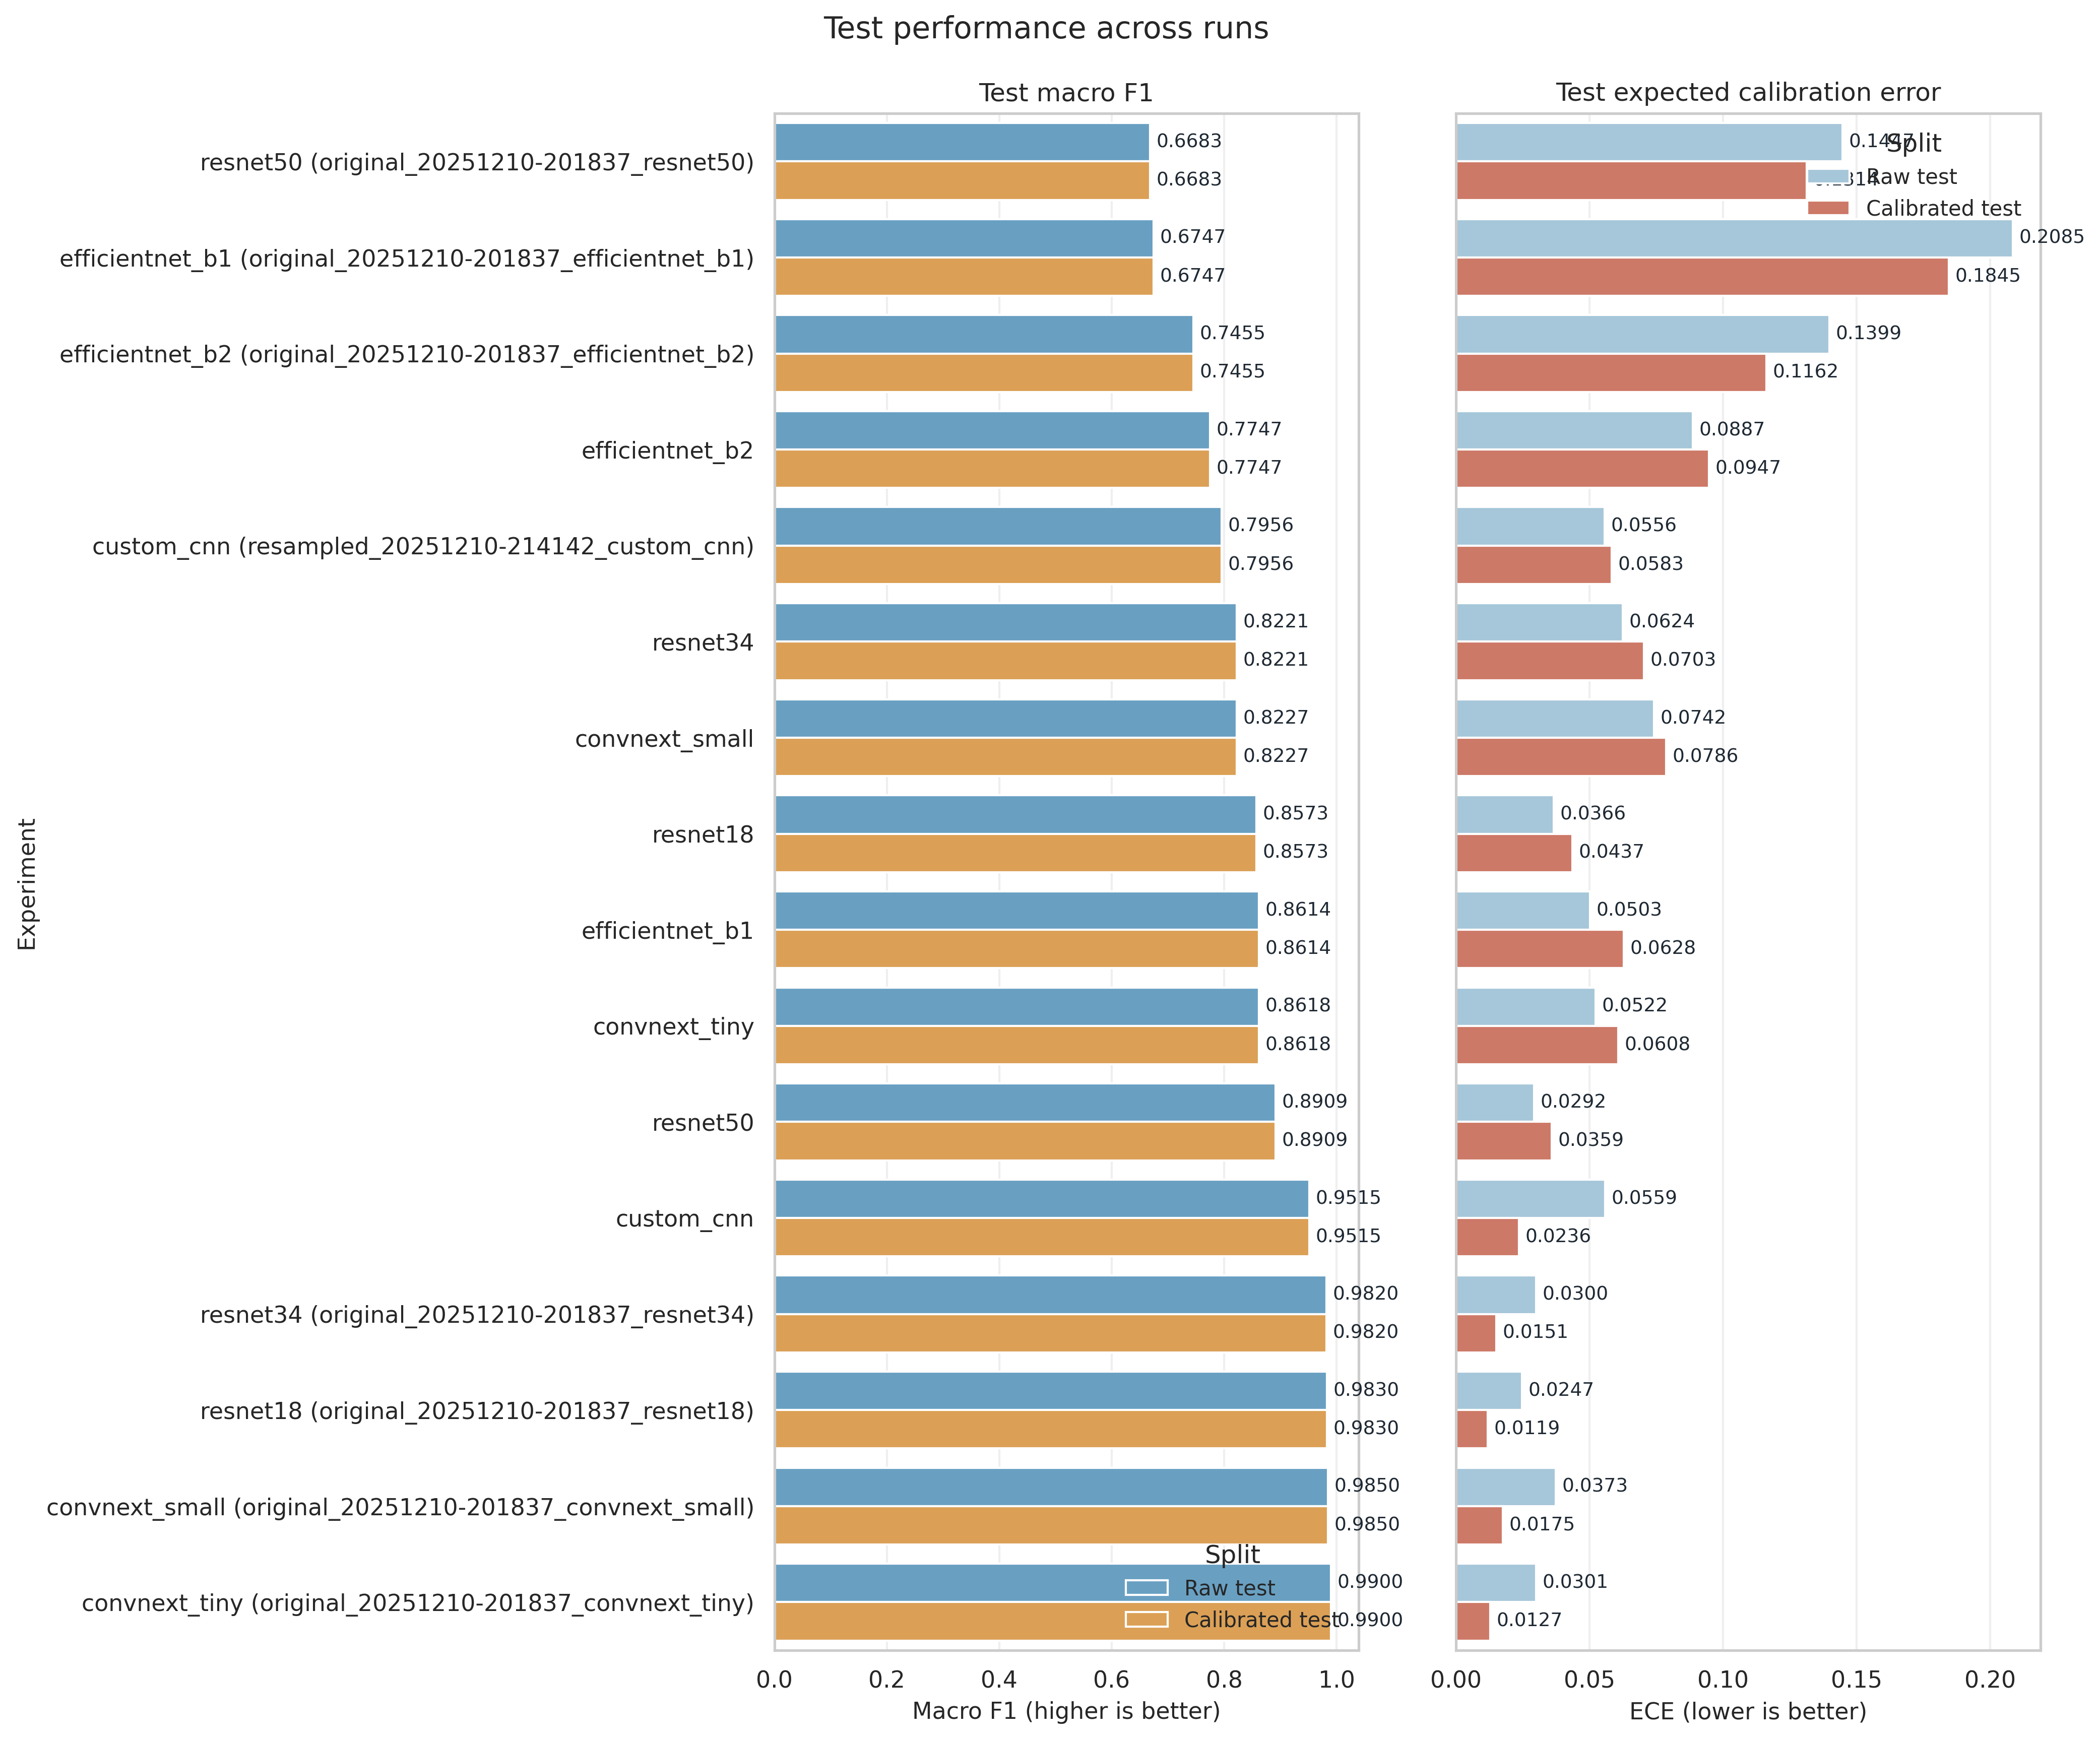

/tmp/ipykernel_35240/2092780518.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


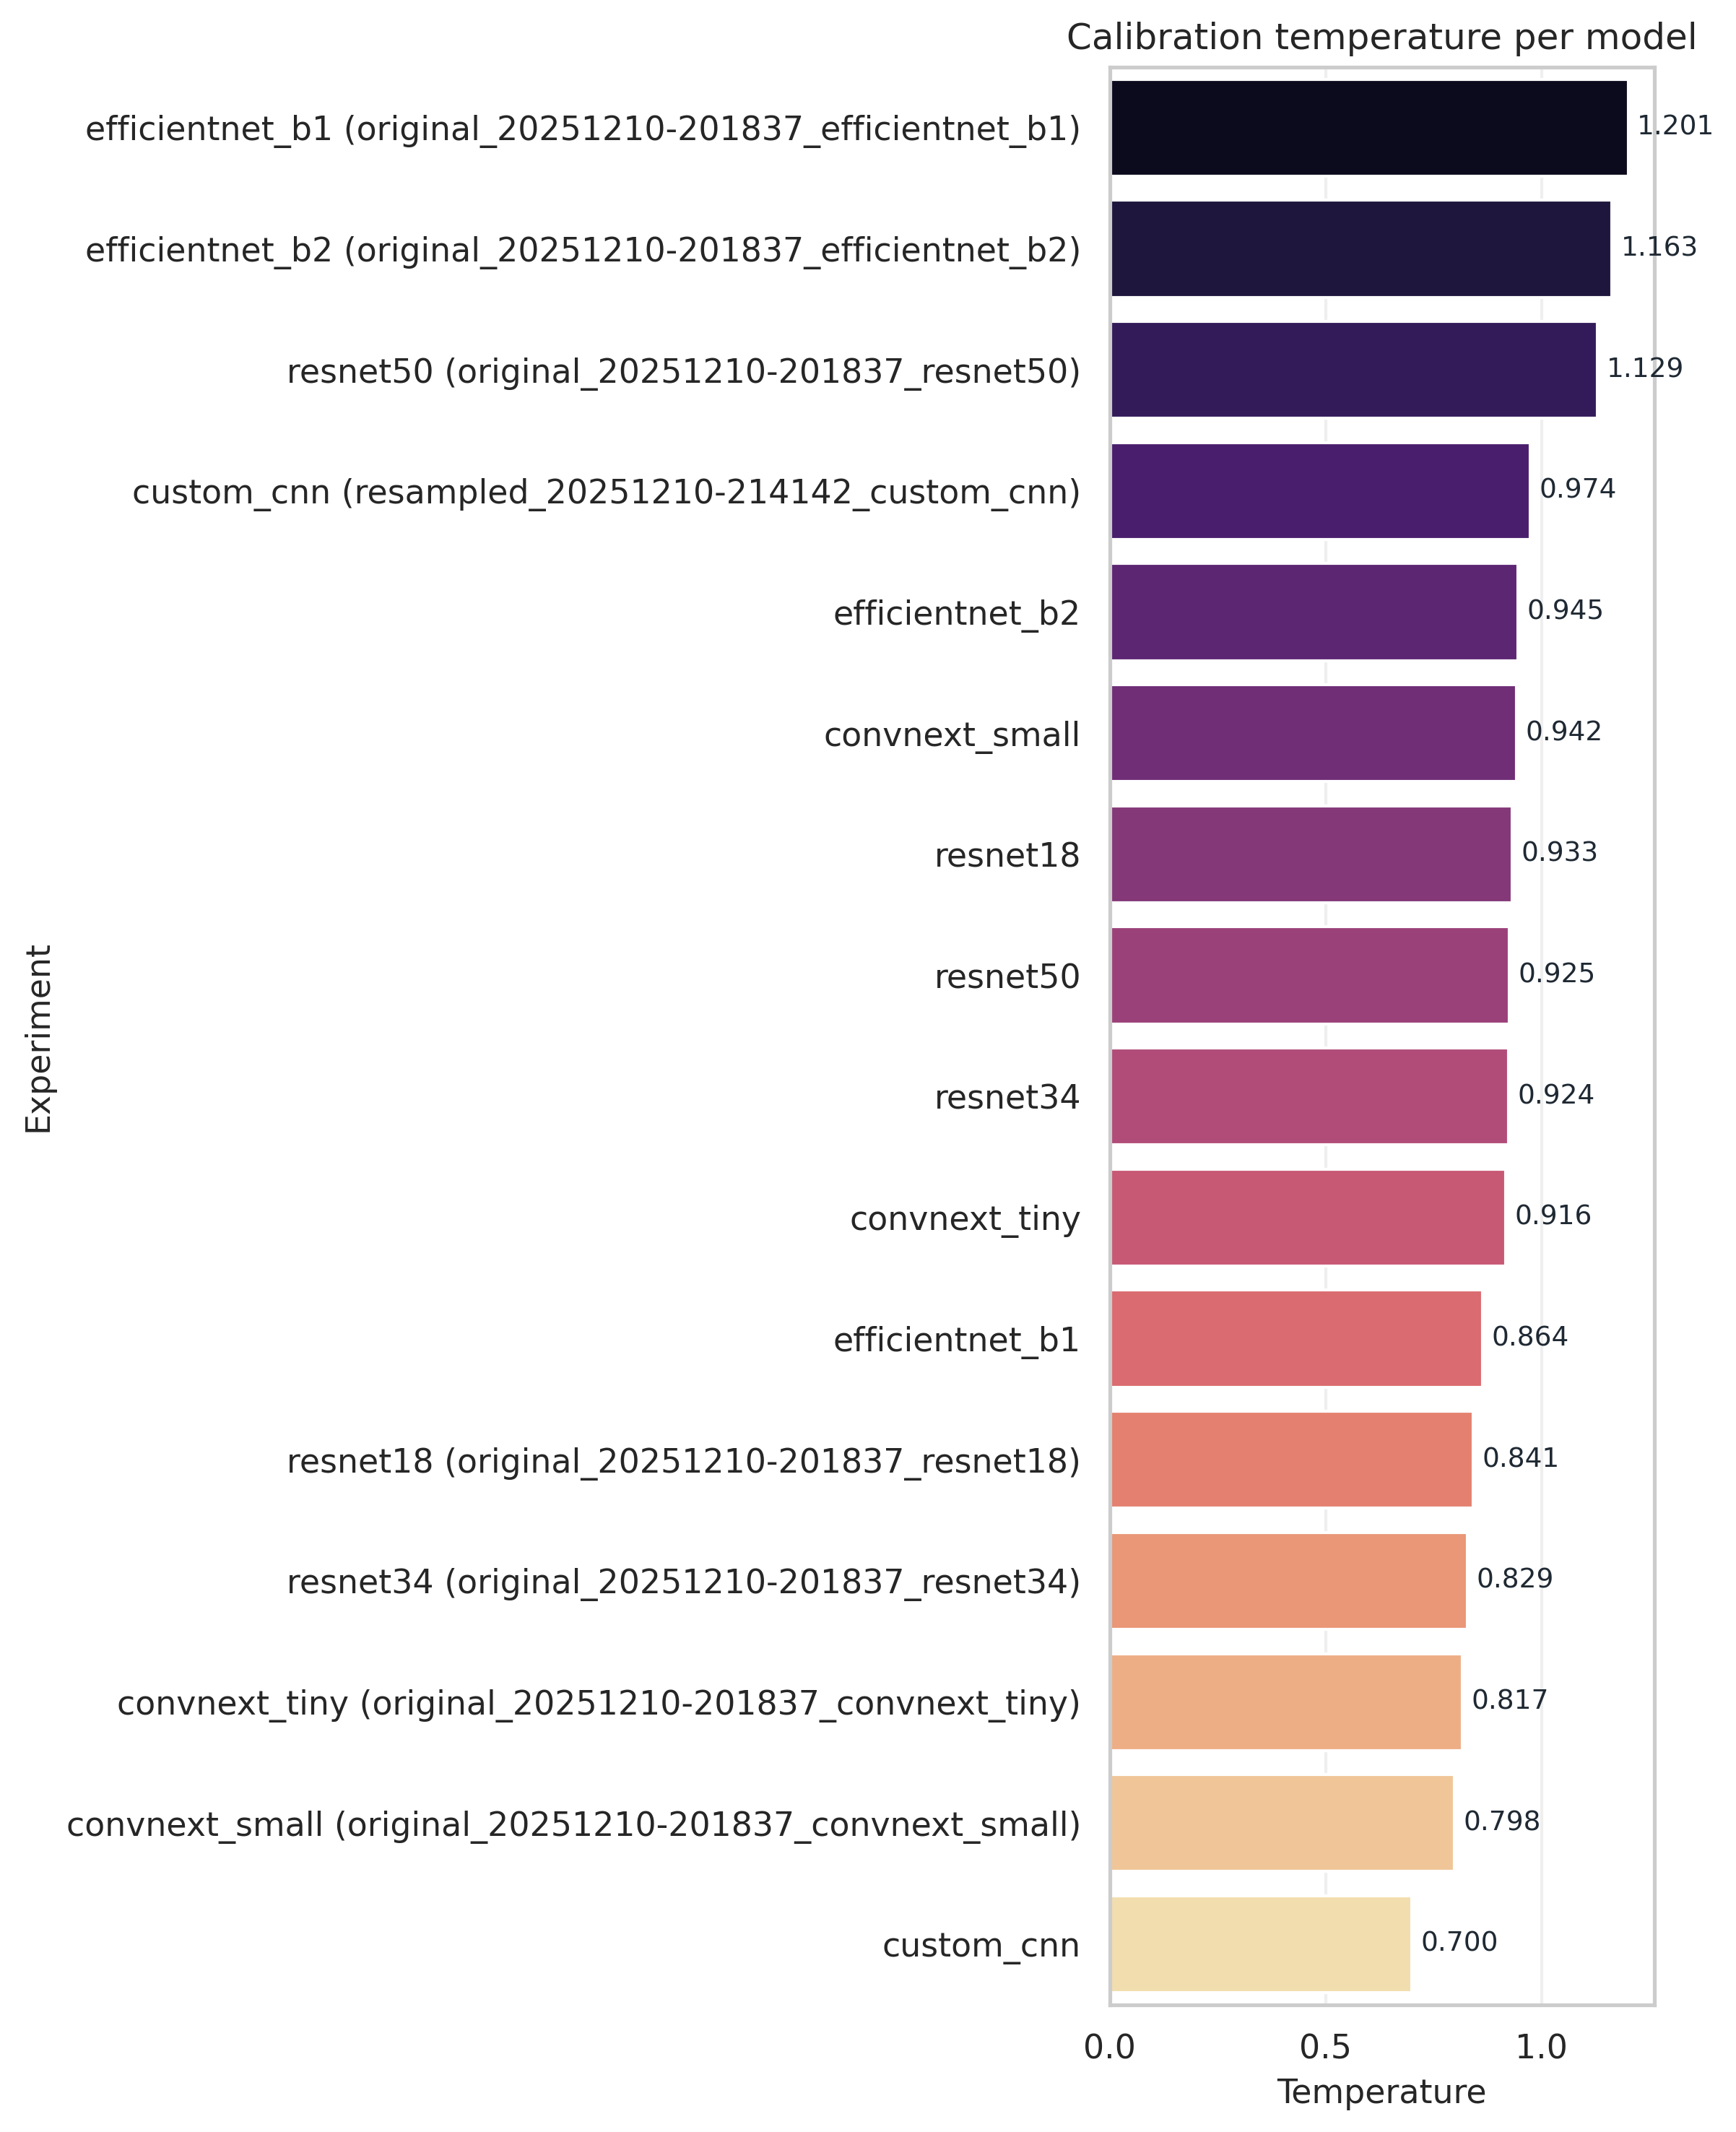

In [21]:
if comparison_df.empty:
    print("No runs to plot. Ensure training/evaluation outputs exist under training_runs.")
else:
    f1_cols = [c for c in ("test_raw_macro_f1", "test_calibrated_macro_f1") if c in comparison_df.columns]
    ece_cols = [c for c in ("test_raw_ece", "test_calibrated_ece") if c in comparison_df.columns]

    if f1_cols:
        f1_long = comparison_df.melt(
            id_vars=["experiment"],
            value_vars=f1_cols,
            var_name="split",
            value_name="macro_f1",
        )
        split_labels = {
            "test_raw_macro_f1": "Raw test",
            "test_calibrated_macro_f1": "Calibrated test",
        }
        f1_long["split"] = f1_long["split"].map(split_labels)
        order = (
            f1_long.groupby("experiment")[["macro_f1"]]
            .max()
            .sort_values("macro_f1", ascending=True)
            .index.tolist()
        )

        height = max(6, 0.6 * len(order) + 2)
        fig, axes = plt.subplots(
            1,
            2 if ece_cols else 1,
            figsize=(14 if ece_cols else 10, height),
            sharey=True,
        )
        if not isinstance(axes, (list, np.ndarray)):
            axes = [axes]

        sns.barplot(
            data=f1_long,
            x="macro_f1",
            y="experiment",
            hue="split",
            order=order,
            palette=["#5aa3d1", "#f1a340"],
            orient="h",
            ax=axes[0],
        )
        axes[0].set_title("Test macro F1")
        axes[0].set_xlabel("Macro F1 (higher is better)")
        axes[0].set_ylabel("Experiment")
        axes[0].grid(axis="x", alpha=0.3)
        annotate_bars(axes[0], fmt="{:.4f}", padding=3)
        axes[0].legend(title="Split", loc="lower right", frameon=False)
        f1_max = f1_long["macro_f1"].max()
        if pd.notna(f1_max):
            axes[0].set_xlim(0, f1_max * 1.05)

        if ece_cols:
            ece_long = comparison_df.melt(
                id_vars=["experiment"],
                value_vars=ece_cols,
                var_name="split",
                value_name="ece",
            )
            ece_labels = {
                "test_raw_ece": "Raw test",
                "test_calibrated_ece": "Calibrated test",
            }
            ece_long["split"] = ece_long["split"].map(ece_labels)
            sns.barplot(
                data=ece_long,
                x="ece",
                y="experiment",
                hue="split",
                order=order if order else None,
                palette=["#9ecae1", "#de6e56"],
                orient="h",
                ax=axes[1],
            )
            axes[1].set_title("Test expected calibration error")
            axes[1].set_xlabel("ECE (lower is better)")
            axes[1].set_ylabel("")
            axes[1].grid(axis="x", alpha=0.3)
            annotate_bars(axes[1], fmt="{:.4f}", padding=3)
            ece_max = ece_long["ece"].max()
            if pd.notna(ece_max):
                axes[1].set_xlim(0, ece_max * 1.05)
            axes[1].legend(title="Split", loc="upper right", frameon=False)

        fig.suptitle("Test performance across runs", y=0.99)
        fig.tight_layout()
        fig.savefig(PLOTS_DIR / "test_performance_bars.pdf", bbox_inches="tight")
        plt.show()

    if "temperature" in comparison_df.columns:
        fig, ax = plt.subplots(figsize=(8, max(4, 0.5 * len(comparison_df) + 2)))
        temp_sorted = comparison_df.sort_values("temperature", ascending=False)
        sns.barplot(
            data=temp_sorted,
            x="temperature",
            y="experiment",
            palette="magma",
            orient="h",
            ax=ax,
        )
        ax.set_title("Calibration temperature per model")
        ax.set_xlabel("Temperature")
        ax.set_ylabel("Experiment")
        annotate_bars(ax, fmt="{:.3f}", padding=3)
        ax.grid(axis="x", alpha=0.3)
        fig.tight_layout()
        fig.savefig(PLOTS_DIR / "temperature_per_model.pdf", bbox_inches="tight")
        plt.show()


## Validation metric trajectories

Macro precision/recall/F1 and calibration error over epochs for each experiment. Best epoch per metric is marked on each line.

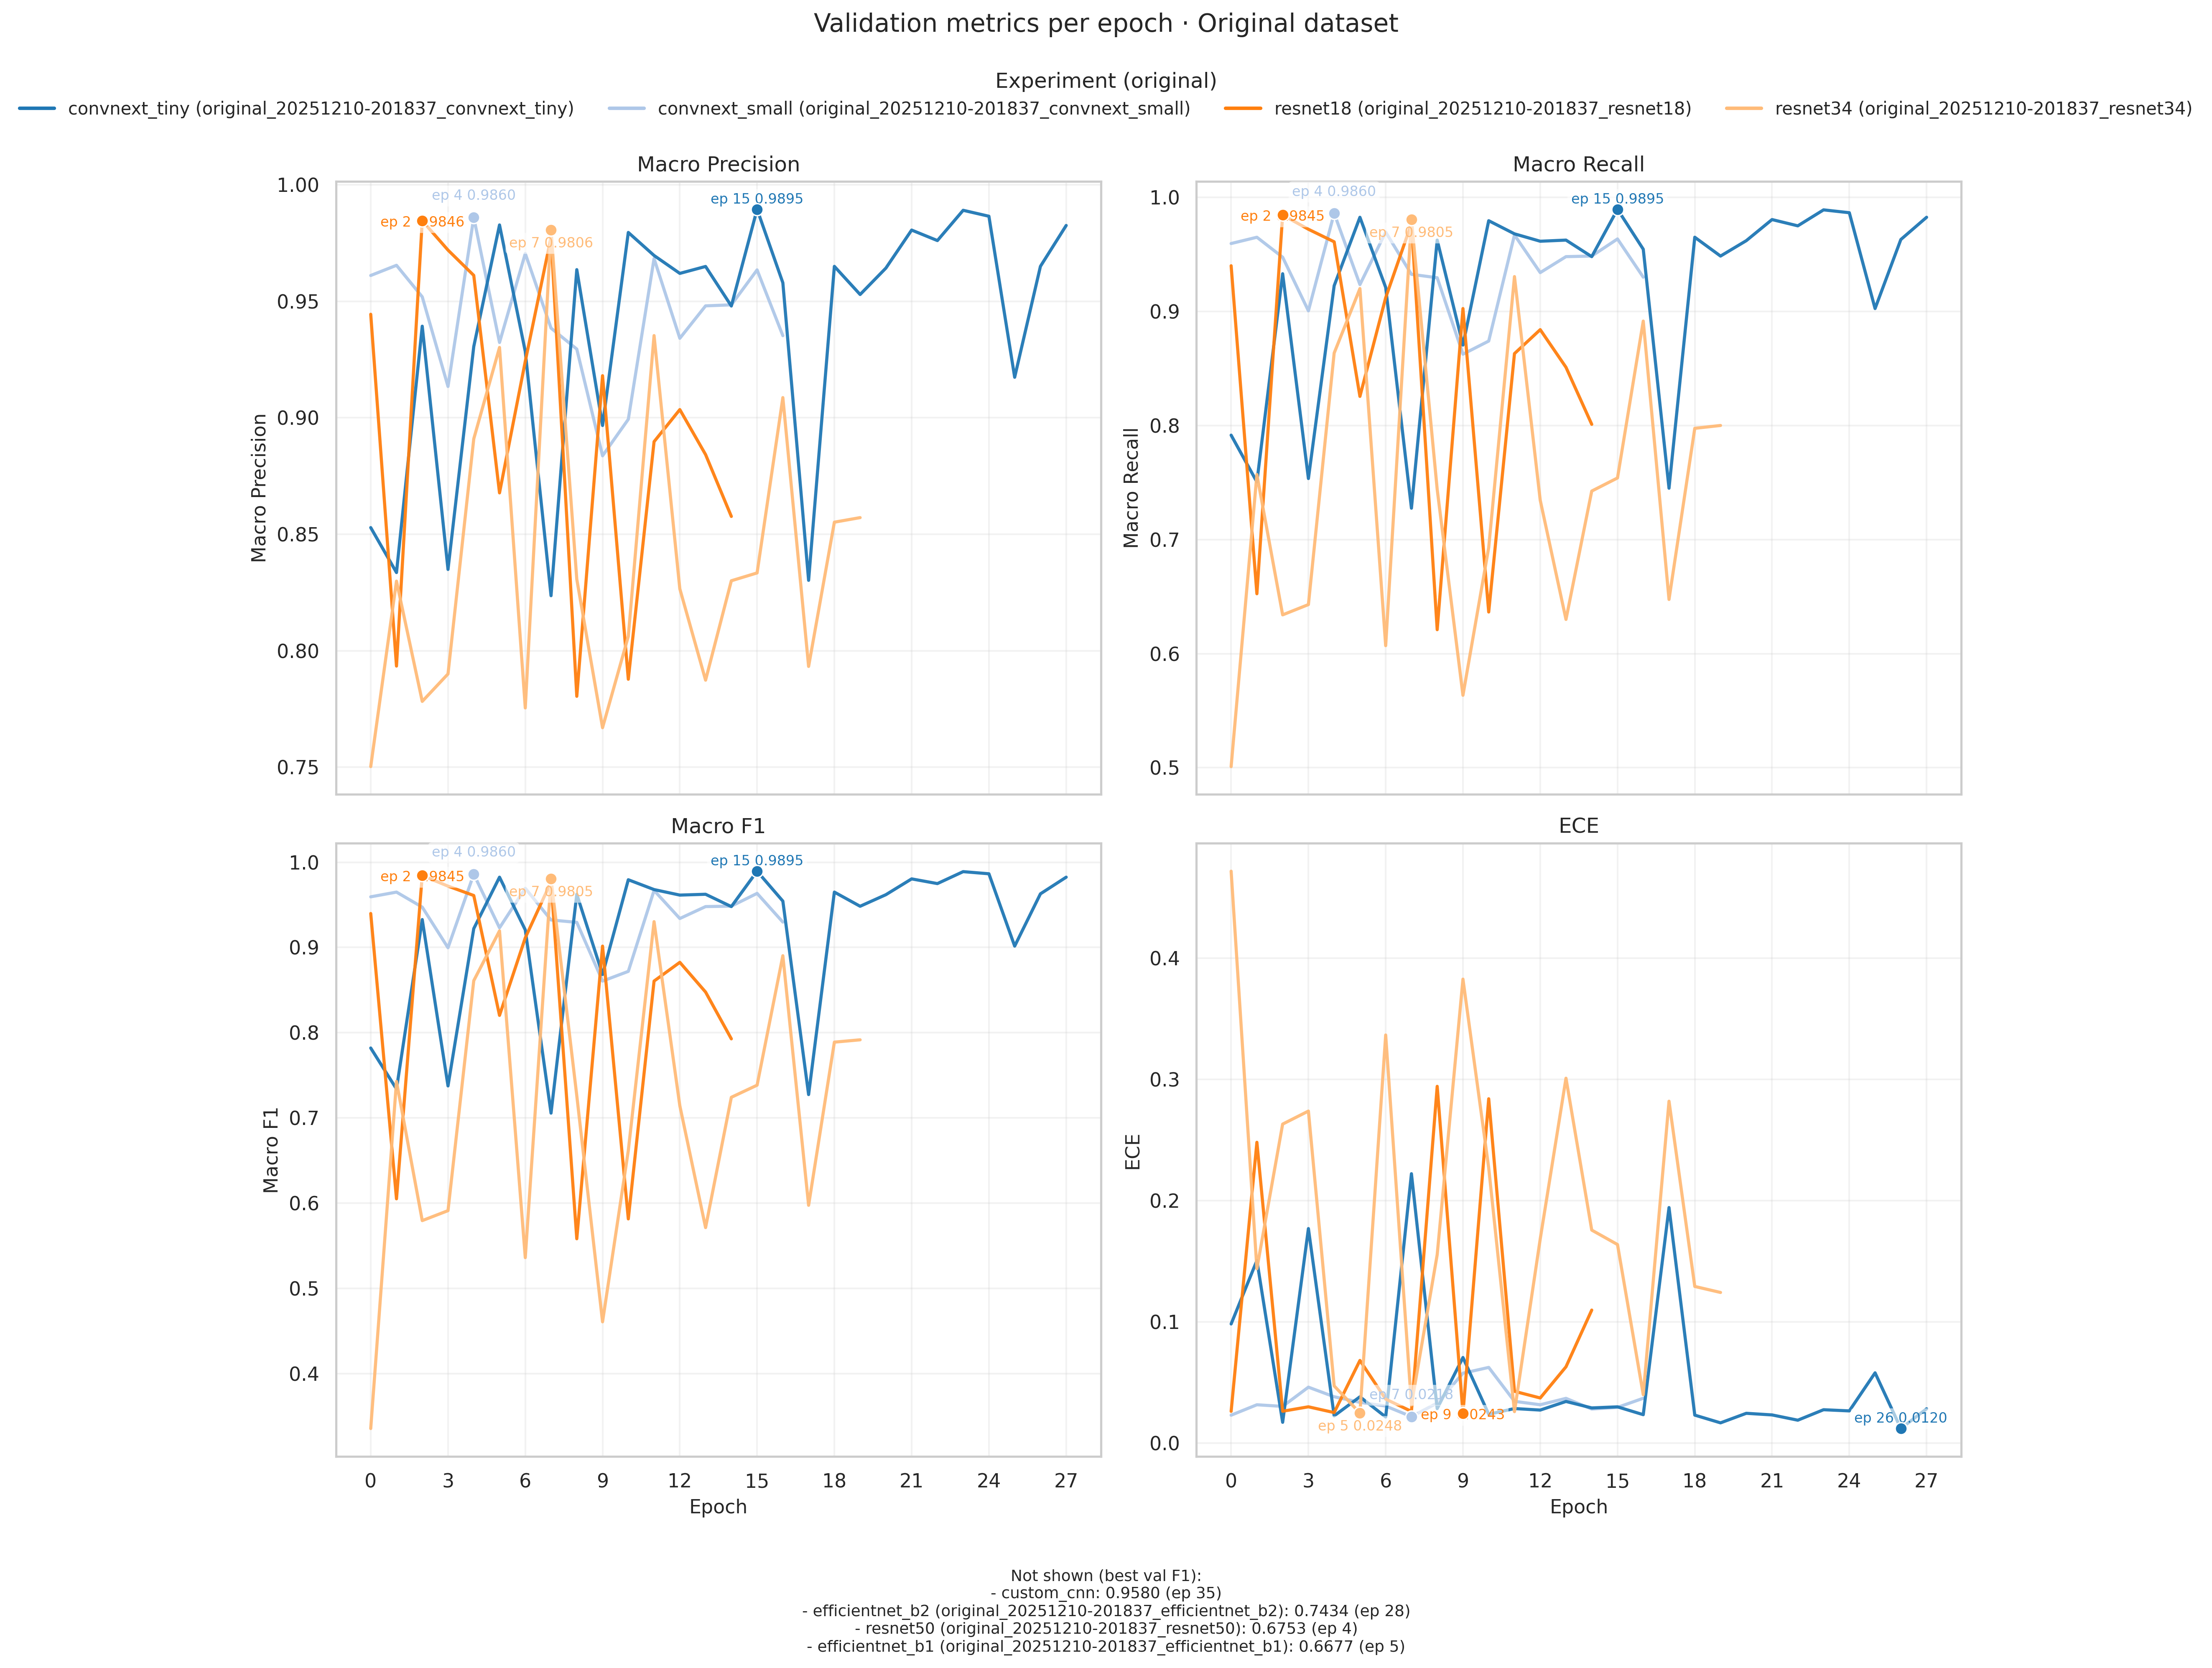

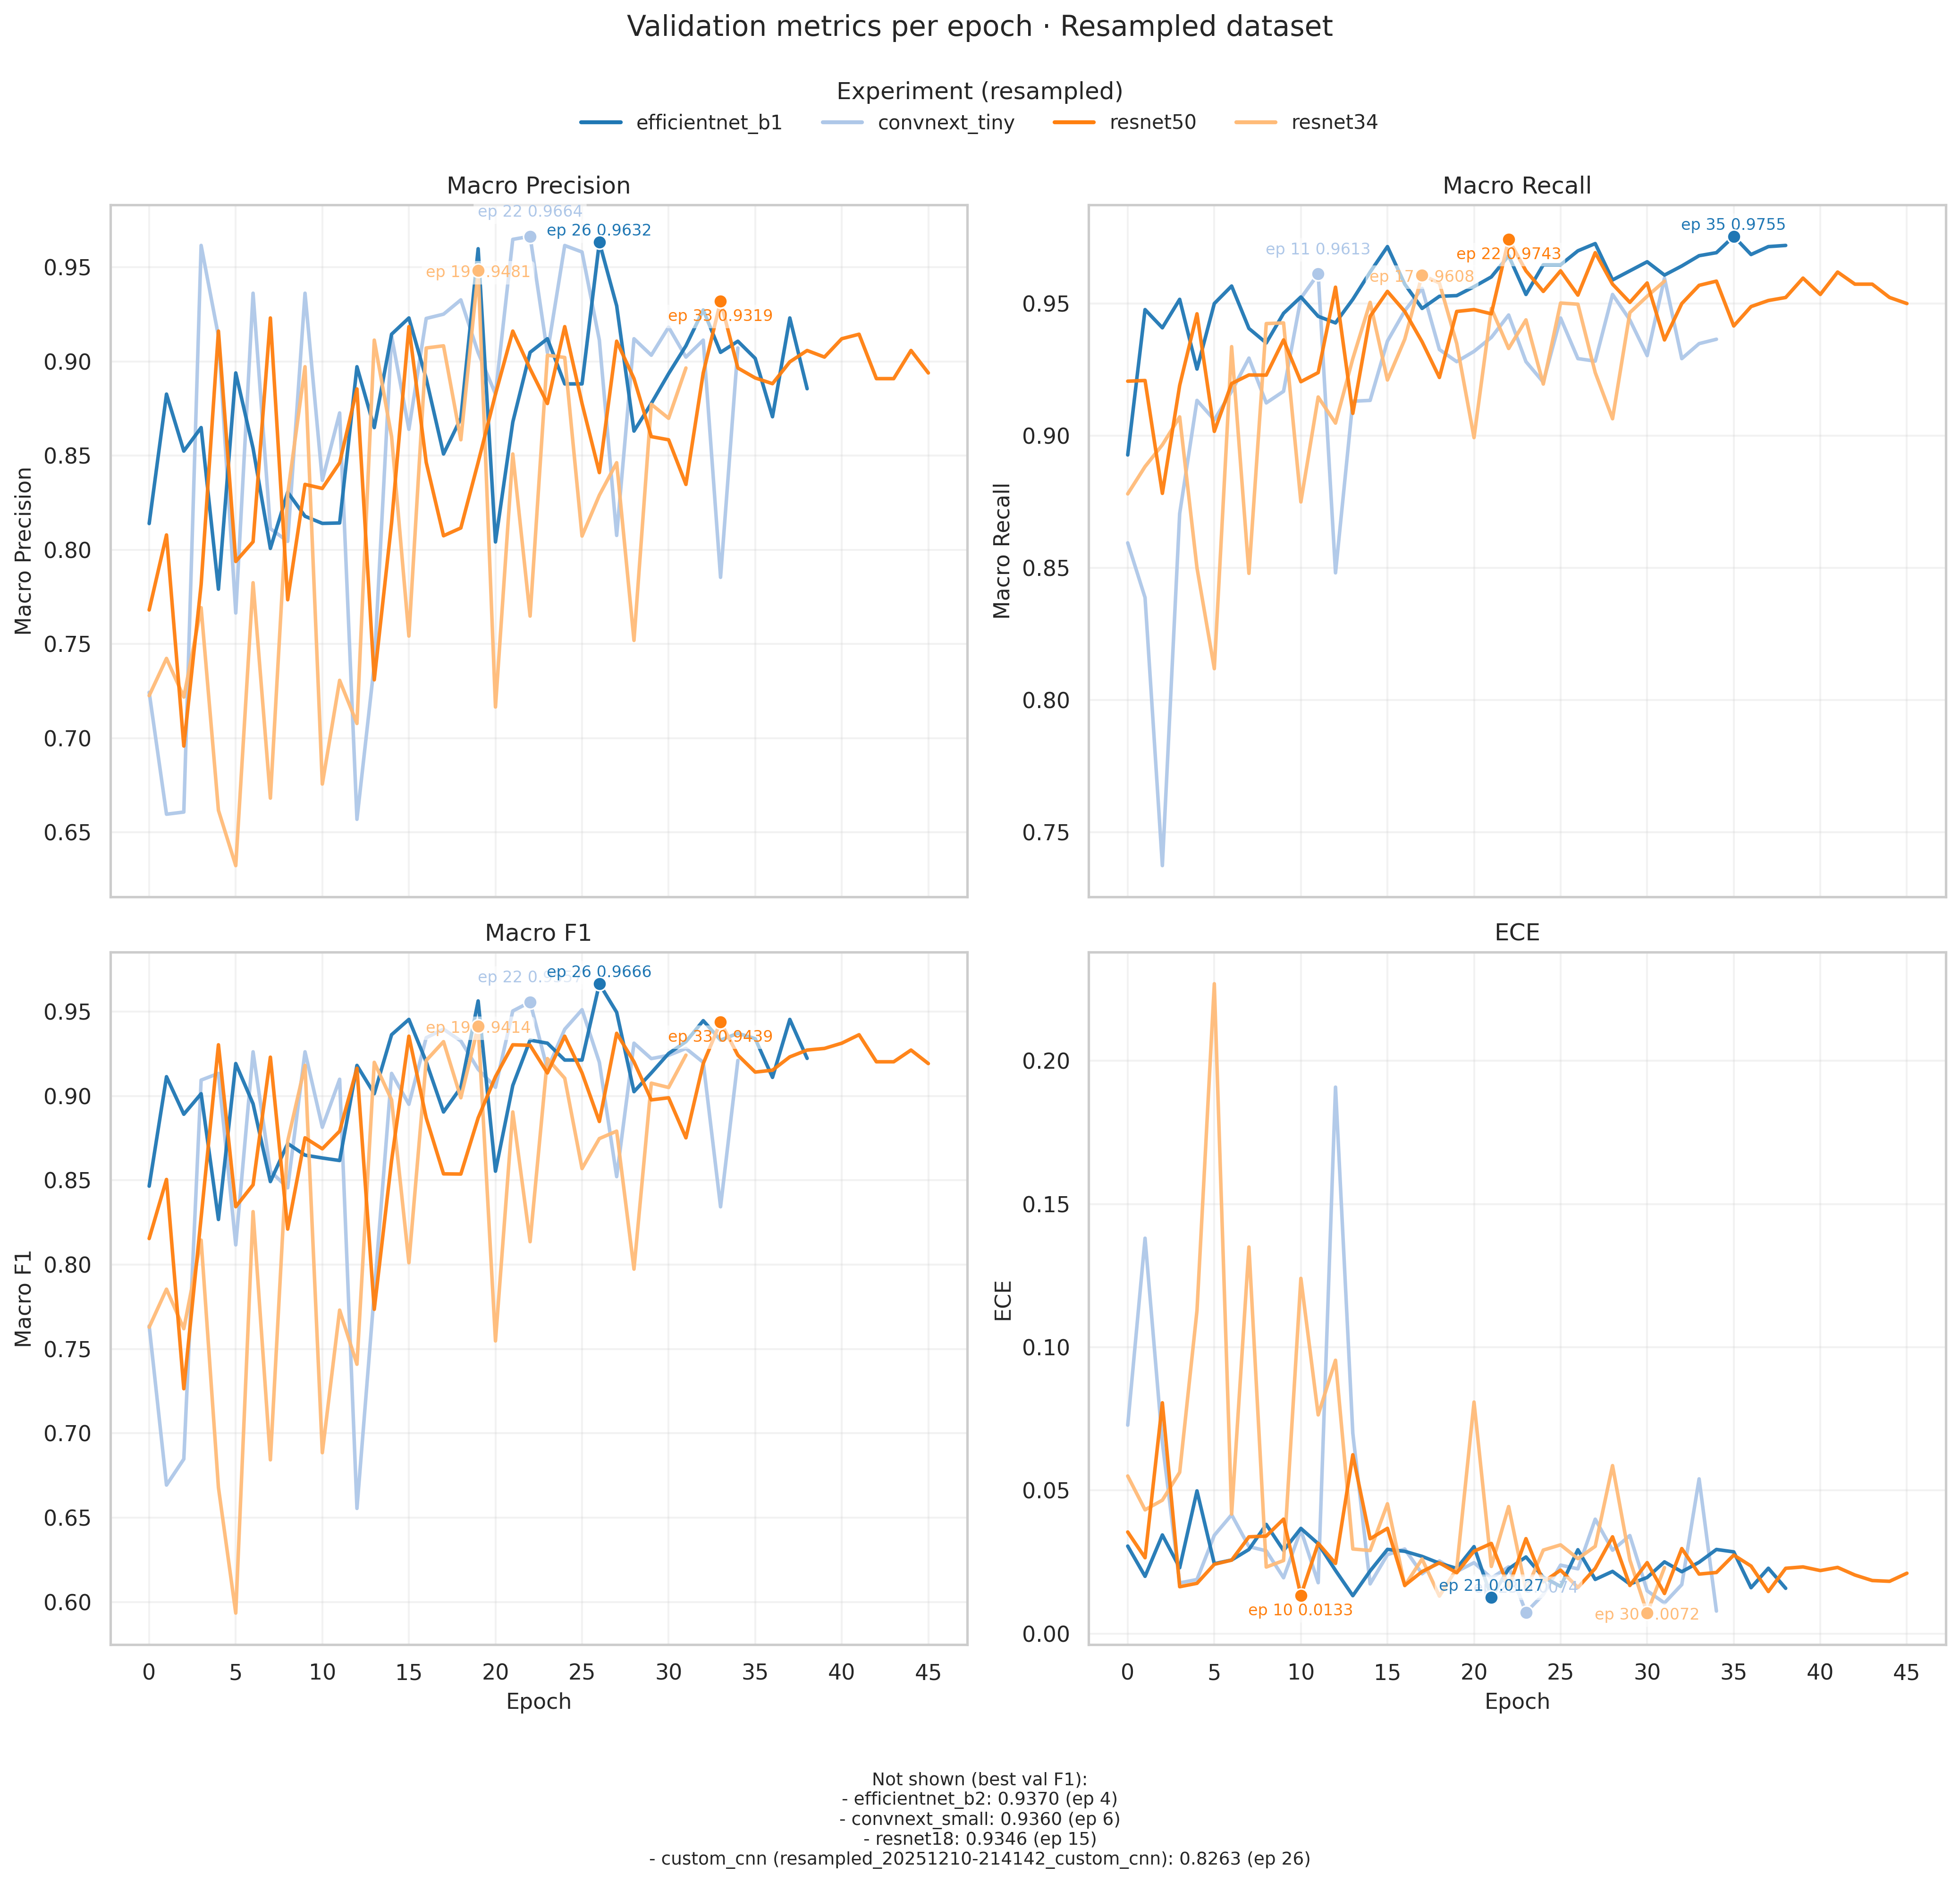

In [23]:
if history_df.empty:
    print("No training histories found for trajectories.")
else:
    metric_specs = [
        ("val/macro_precision", "Macro Precision", True),
        ("val/macro_recall", "Macro Recall", True),
        ("val/macro_f1", "Macro F1", True),
        ("val/ece", "ECE", False),
    ]

    best_metric_col = "best_val_macro_f1" if "best_val_macro_f1" in comparison_df.columns else None

    def rank_experiments(df: pd.DataFrame) -> pd.DataFrame:
        if best_metric_col:
            return df.sort_values(best_metric_col, ascending=False)
        # fallback: use max val/macro_f1 from history
        scores = []
        for exp in df["experiment"]:
            hist = history_df[history_df["experiment"] == exp]
            scores.append(hist["val/macro_f1"].max() if "val/macro_f1" in hist else np.nan)
        df = df.copy()
        df["_score"] = scores
        return df.sort_values("_score", ascending=False)

    def plot_group(dataset_tag: str):
        group_runs = comparison_df[comparison_df.get("dataset", "original") == dataset_tag]
        if group_runs.empty:
            print(f"No runs found for dataset tag '{dataset_tag}'.")
            return

        ranked_full = rank_experiments(group_runs)
        ranked = ranked_full.head(8)  # cap per figure to avoid clutter
        visible = ranked.head(4)
        hidden = ranked.iloc[4:]
        extra_omitted = len(ranked_full) - len(ranked)
        visible_exps = visible["experiment"].tolist()
        subset_hist = history_df[history_df["experiment"].isin(visible_exps)]
        if subset_hist.empty:
            print(f"No history found for visible runs in '{dataset_tag}'.")
            return

        palette = build_palette(visible_exps)
        fig, axes = plt.subplots(2, 2, figsize=(14, max(8, 1.4 * len(visible_exps) + 6)), sharex=True)
        axes = axes.flatten()

        for ax, (metric, label, higher_is_better) in zip(axes, metric_specs):
            if metric not in subset_hist.columns:
                ax.set_visible(False)
                continue

            metric_df = subset_hist.dropna(subset=[metric])
            if metric_df.empty:
                ax.set_visible(False)
                continue

            sns.lineplot(
                data=metric_df,
                x="epoch",
                y=metric,
                hue="experiment",
                palette=palette,
                linewidth=1.8,
                alpha=0.95,
                ax=ax,
                legend=False,
            )

            annotate_best_points(ax, metric_df, metric, palette, higher_is_better=higher_is_better)

            ax.set_title(label)
            ax.set_ylabel(label if higher_is_better else f"{label}")
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))
            ax.grid(alpha=0.25)

        for ax in axes:
            if ax.get_visible():
                ax.set_xlabel("Epoch")

        legend_handles = [Line2D([0], [0], color=palette[exp], lw=2) for exp in visible_exps]
        fig.legend(
            legend_handles,
            visible_exps,
            title=f"Experiment ({dataset_tag})",
            loc="upper center",
            ncol=min(4, len(visible_exps)),
            frameon=False,
            bbox_to_anchor=(0.5, 1.02),
        )

        note_lines = []
        if not hidden.empty:
            note_lines.append("Not shown (best val F1):")
            for _, row in hidden.iterrows():
                best_val = row.get("best_val_macro_f1")
                best_epoch = row.get("best_epoch")
                val_str = f"{best_val:.4f}" if pd.notna(best_val) else "n/a"
                epoch_str = f"ep {int(best_epoch)}" if pd.notna(best_epoch) else "ep n/a"
                note_lines.append(f"- {row['experiment']}: {val_str} ({epoch_str})")
        else:
            note_lines.append("All runs in this dataset are shown")
        if extra_omitted > 0:
            note_lines.append(f"(+{extra_omitted} additional run(s) omitted beyond top 8)")

        fig.suptitle(f"Validation metrics per epoch · {dataset_tag.capitalize()} dataset", y=1.05)
        fig.text(0.5, -0.02, "\n".join(note_lines), ha="center", va="top", fontsize=9)
        fig.tight_layout()
        fig.savefig(PLOTS_DIR / f"validation_metrics_{dataset_tag}.pdf", bbox_inches="tight")
        plt.show()

    plot_group("original")
    plot_group("resampled")
